In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
import warnings
warnings.filterwarnings("ignore")
import wikipediaapi 

load_dotenv()

my_agent = os.getenv('USER_AGENT')


wiki_wiki = wikipediaapi.Wikipedia(
    user_agent=my_agent,
    language='en'
)

url="https://en.wikipedia.org/wiki/2023_Cricket_World_Cup"


In [4]:
from langchain_community.document_loaders import AsyncHtmlLoader
loader = AsyncHtmlLoader(url)
html_data = loader.load()

Fetching pages: 100%|##########| 1/1 [00:00<00:00,  1.15it/s]


In [5]:
import textwrap
import wikipedia 
from langchain_community.document_loaders import WikipediaLoader
wikipedia.set_user_agent("MyStudyProject/1.0 (contact@example.com)")

loader = WikipediaLoader(query=url, load_max_docs=1)
html_data = loader.load()


print(textwrap.fill(f"First 1000 characters of extracted content -\n\n{html_data[0].page_content[:1000]}", width=150))

First 1000 characters of extracted content -  International cricket matches are played between the teams representing their nations, administrated by
the International Cricket Council. The main forms are Test matches, ODI matches and T20I matches. An upcoming form, scheduled to commence in January
2026, is Test Twenty. Most games are played as part of "tours" when one nation travels to another for a number of weeks or months and plays a number
of matches of various sorts against the host nation. World Cups featuring several countries at once, are organized by the ICC. The ICC is also
responsible for cricket games played at multi-sport events such as Olympic Games, Commonwealth Games, African Games, Asian Games, South Asian Games
and Pacific Games. In addition to ICC's administration, there are also five regional bodies, Asian Cricket Council, Africa Cricket Association, ICC
Europe, ICC Americas and ICC East Asia-Pacific which aim to promote the sport of cricket in their respective cont

In [6]:
print(f"Metadata information - \n\n{html_data[0].metadata}")


Metadata information - 

{'title': 'International cricket', 'summary': 'International cricket matches are played between the teams representing their nations, administrated by the International Cricket Council. The main forms are Test matches, ODI matches and T20I matches. An upcoming form, scheduled to commence in January 2026, is Test Twenty.\nMost games are played as part of "tours" when one nation travels to another for a number of weeks or months and plays a number of matches of various sorts against the host nation. World Cups featuring several countries at once, are organized by the ICC. The ICC is also responsible for cricket games played at multi-sport events such as Olympic Games, Commonwealth Games, African Games, Asian Games, South Asian Games and Pacific Games.\nIn addition to ICC\'s administration, there are also five regional bodies, Asian Cricket Council, Africa Cricket Association, ICC Europe, ICC Americas and ICC East Asia-Pacific which aim to promote the sport of cri

In [7]:
from langchain_community.document_transformers import Html2TextTransformer
html2text = Html2TextTransformer()
html_data_transformed = html2text.transform_documents(html_data)

In [8]:
print(f"First 100 characters of extracted content -\n\n{html_data_transformed[0].page_content[:1000]}")

First 100 characters of extracted content -

International cricket matches are played between the teams representing their
nations, administrated by the International Cricket Council. The main forms
are Test matches, ODI matches and T20I matches. An upcoming form, scheduled to
commence in January 2026, is Test Twenty. Most games are played as part of
"tours" when one nation travels to another for a number of weeks or months and
plays a number of matches of various sorts against the host nation. World Cups
featuring several countries at once, are organized by the ICC. The ICC is also
responsible for cricket games played at multi-sport events such as Olympic
Games, Commonwealth Games, African Games, Asian Games, South Asian Games and
Pacific Games. In addition to ICC's administration, there are also five
regional bodies, Asian Cricket Council, Africa Cricket Association, ICC
Europe, ICC Americas and ICC East Asia-Pacific which aim to promote the sport
of cricket in their respective conti

In [9]:
from langchain_classic.text_splitter import CharacterTextSplitter 
text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=100,
)

text_chunk = text_splitter.create_documents([html_data_transformed[0].page_content])
print(f"The number of chunk created: {len(text_chunk)}")


The number of chunk created: 5


In [10]:
text_chunk[4].page_content[-200:]

" one ICC Champions Trophy,\none ICC Women's Champions Trophy, two men's T20 World Cups and two women's T20\nWorld Cups. == ICC tournaments == == ICC qualifiers == == Multi-sport events\n== Cricket was or"

In [11]:
if text_chunk:
	idx = 5 if len(text_chunk) > 5 else -1
	print(text_chunk[idx].page_content[:200])
else:
	print("text_chunk is empty")

known as an "ICC Events cycle" since 2024. Each cycle consists of one men's
Cricket World Cup, one women's Cricket World Cup, one ICC Champions Trophy,
one ICC Women's Champions Trophy, two men's T20 


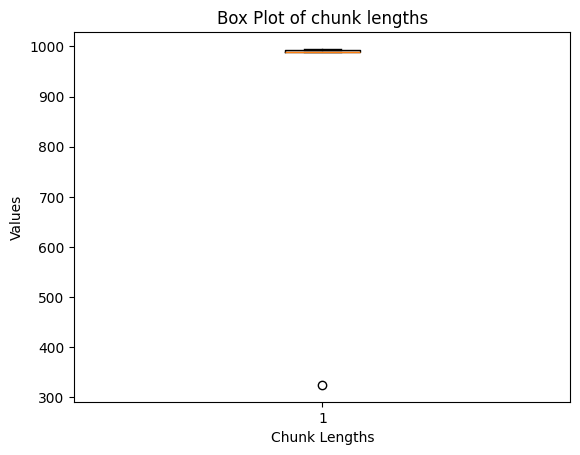

The median chunk length is : 989.0
The average chunk length is : 857.8
The minimum chunk length is : 325
The max chunk length is : 995
The 75th percentile chunk length is : 992.0
The 25th percentile chunk length is : 988.0


In [12]:
import matplotlib.pyplot as plt
import numpy as np


data = [len(doc.page_content) for doc in text_chunk]

plt.boxplot(data)  
plt.title('Box Plot of chunk lengths') 
plt.xlabel('Chunk Lengths')  
plt.ylabel('Values') 

plt.show()

print(f"The median chunk length is : {round(np.median(data),2)}")
print(f"The average chunk length is : {round(np.mean(data),2)}")
print(f"The minimum chunk length is : {round(np.min(data),2)}")
print(f"The max chunk length is : {round(np.max(data),2)}")
print(f"The 75th percentile chunk length is : {round(np.percentile(data, 75),2)}")
print(f"The 25th percentile chunk length is : {round(np.percentile(data, 25),2)}")

In [13]:
loader = AsyncHtmlLoader (url)

html_data = loader.load()

Fetching pages: 100%|##########| 1/1 [00:00<00:00,  1.57it/s]


In [14]:
from langchain_text_splitters import HTMLSectionSplitter
sections_to_split_on = [
    ("h1", "Header 1"),
    ("h2", "Header 2"),
    ("table", "Table"),
    ("p", "P"),
]

splitter = HTMLSectionSplitter(sections_to_split_on)
split_conter = splitter.split_text(html_data[0].page_content)

In [15]:
split_conter[:10]

[Document(metadata={'Header 1': '#TITLE#'}, page_content='Jump to content \n \n \n \n \n \n \n \n Main menu \n \n \n \n \n \n Main menu \n move to sidebar \n hide \n \n \n \n\t\tNavigation\n\t \n \n \n Main page \n Contents \n Current events \n Random article \n About Wikipedia \n Contact us \n \n \n \n \n \n\t\tContribute\n\t \n \n \n Help \n Learn to edit \n Community portal \n Recent changes \n Upload file \n Special pages \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n Search \n \n \n \n \n \n \n \n \n \n \n \n Search \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n Appearance \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n Donate \n \n \n Create account \n \n \n Log in \n \n \n \n \n \n \n \n \n Personal tools \n \n \n \n \n \n Donate \n   Create account \n   Log in \n \n \n \n \n \n \n \n \n \n \n \n \n  CentralNotice'),
 Document(metadata={'Header 2': 'Contents'}, page_content="Contents \n move to sidebar \n hide \n \n \n \n \n (Top) \n \n \

In [16]:
(len(split_conter))

232

In [17]:
from collections import Counter
class_counter = Counter()

for doc in split_conter:
    document_class = next(iter(doc.metadata.keys()))
    class_counter[document_class] += 1

print(class_counter)

Counter({'Table': 188, 'P': 28, 'Header 2': 14, 'Header 1': 2})


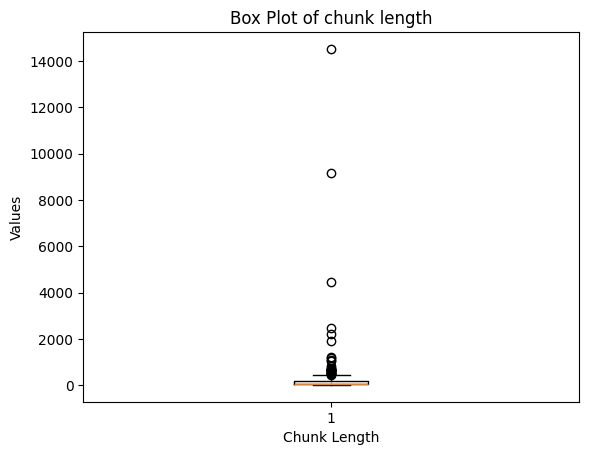

The median chunk lenght is : 71.0
The average chunk lenght is : 299.97
The minimum chunk lenght is : 12
The max chunk lenght is : 14520
The 75th percentile chunk length is : 195.5
The 25th percentile chunk length is : 37.0


In [18]:
data = [len(doc.page_content) for doc in split_conter]
plt.boxplot(data)
plt.title('Box Plot of chunk length')
plt.xlabel('Chunk Length')
plt.ylabel('Values')

plt.show()

print(f"The median chunk lenght is : {round(np.median(data),2)}")
print(f"The average chunk lenght is : {round(np.mean(data),2)}")
print(f"The minimum chunk lenght is : {round(np.min(data),2)}")
print(f"The max chunk lenght is : {round(np.max(data),2)}")
print(f"The 75th percentile chunk length is : {round(np.percentile(data, 75),2)}")
print(f"The 25th percentile chunk length is : {round(np.percentile(data, 25),2)}")

In [19]:
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
separators=["\n\n","\n","."], 
chunk_overlap=100, 
)

final_chunks=text_splitter.split_documents(split_conter)


print(f"The number of chunks created : {len(final_chunks)}")

The number of chunks created : 238


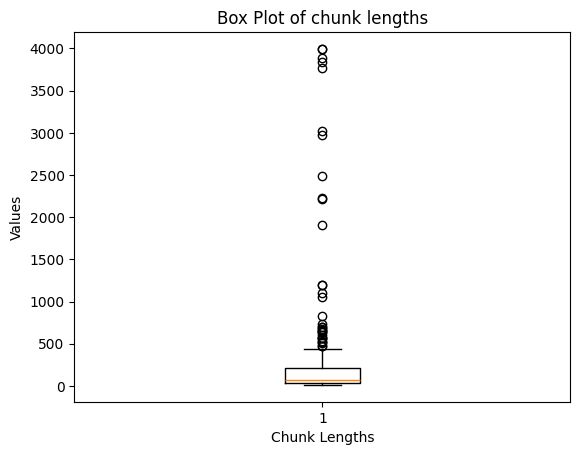

The median chunk lenght is : 71.0
The average chunk lenght is : 292.9
The minimum chunk lenght is : 12
The max chunk lenght is : 3994
The 75th percentile chunk length is : 207.5
The 25th percentile chunk length is : 40.0


In [20]:
data = [len(doc.page_content) for doc in final_chunks]

plt.boxplot(data)  
plt.title('Box Plot of chunk lengths')  
plt.xlabel('Chunk Lengths')  
plt.ylabel('Values')  

plt.show()

print(f"The median chunk lenght is : {round(np.median(data),2)}")
print(f"The average chunk lenght is : {round(np.mean(data),2)}")
print(f"The minimum chunk lenght is : {round(np.min(data),2)}")
print(f"The max chunk lenght is : {round(np.max(data),2)}")
print(f"The 75th percentile chunk length is : {round(np.percentile(data, 75),2)}")
print(f"The 25th percentile chunk length is : {round(np.percentile(data, 25),2)}")

In [21]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
hf_embeddings = embeddings.embed_documents([chunk.page_content for chunk in final_chunks])

In [22]:
print(f"The lenght of the embeddings vector is {len(hf_embeddings[0])}")
print(f"The embeddings object is an array of {len(hf_embeddings)} X {len(hf_embeddings[0])}")

The lenght of the embeddings vector is 768
The embeddings object is an array of 238 X 768


In [23]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores.faiss import FAISS

index = faiss.IndexFlatIP(len(hf_embeddings[0]))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

vector_store.add_documents(documents=final_chunks)

['6e483803-9d76-45a4-af6b-34088c36e2d7',
 'b8a4f65d-d07c-440e-9126-5d333a29894f',
 '972de4e1-136e-4198-9b90-e8ab96b1d629',
 'e38e2fc8-8361-403e-bd00-bec9f5699fd0',
 'fcf7c665-1ee6-4d27-a231-0755cc1b0683',
 '78e16534-2549-458e-a083-a4809ef65ab4',
 '31e668d2-2c29-42f1-ba54-e784b53270fe',
 'd26ea5b4-557d-4944-a15d-36a342b69dc9',
 '9bf7f65e-a64d-4ae2-a55f-744722adac64',
 'db8ab65a-dea7-43fd-8d2a-f63267d17d70',
 'ba657e3b-78bd-403d-86ce-a791bc09db74',
 '5ebe375a-c945-4f75-b72c-4363e6ef50d2',
 '0222aa26-be9e-42d5-a5fa-aaa962c1f4b0',
 'abf0f9b5-60d2-4227-9cab-fb17cd46d413',
 '4eca622e-5847-4135-b8cd-e429b1298f1c',
 '1ab1a151-4b08-41ee-8054-464d732e3772',
 'a8aa710e-8366-4190-a99c-b66ebbb3f41b',
 'e57e14be-343b-41b8-a3ae-a1d8e14d27a4',
 '49463c6e-682d-4fb8-be75-ad6a8af1a7c5',
 '47d24963-5e23-4d9d-98e7-3e1050883b09',
 '3d6a07ab-f302-48a1-9684-c99417cce404',
 '41f00f3a-65f1-4e2a-9789-ec9ae9ff6639',
 '3a822025-b959-4910-8d65-eea57e677557',
 '57d61d1f-43a0-4fb9-951a-c4f4fc76454a',
 '487b657a-9647-

In [24]:
vector_store.save_local(folder_path="assets", index_name="CWC_index")

In [25]:
query = "who won the 2023 world cup?"
docs = vector_store.similarity_search(query)
print(docs[0].page_content)

Group stage 
 
 Main article:  2023 Cricket World Cup group stage
